Running into issue where the clustering scale is blown way out by impossible values even after clipping 

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

energy_file = Path(r"C:\NCA_DATA\Clustering\cluster_v3\X_energy_1M_clipped.npy")

X = np.load(energy_file)
print("Shape:", X.shape)
print("dtype:", X.dtype)

# ---------------------------------------------------------------------
# Basic validity checks
# ---------------------------------------------------------------------

print("\nGlobal finite check")
print("finite proportion:", np.isfinite(X).mean())
print("nan count:", np.isnan(X).sum())
print("inf count:", np.isinf(X).sum())

# ---------------------------------------------------------------------
# Per-feature diagnostics
# ---------------------------------------------------------------------

feature_names = [f"feat_{i}" for i in range(X.shape[1])]

summary = []

for j in range(X.shape[1]):
    x = X[:, j]
    finite = np.isfinite(x)
    xf = x[finite]

    summary.append({
        "feature": feature_names[j],
        "n": len(x),
        "n_finite": finite.sum(),
        "n_nan": np.isnan(x).sum(),
        "n_inf": np.isinf(x).sum(),
        "min": np.min(xf) if len(xf) else np.nan,
        "p0_1": np.percentile(xf, 0.1) if len(xf) else np.nan,
        "p1": np.percentile(xf, 1) if len(xf) else np.nan,
        "p50": np.percentile(xf, 50) if len(xf) else np.nan,
        "p99": np.percentile(xf, 99) if len(xf) else np.nan,
        "p99_9": np.percentile(xf, 99.9) if len(xf) else np.nan,
        "max": np.max(xf) if len(xf) else np.nan,
        "mean": np.mean(xf) if len(xf) else np.nan,
        "sd": np.std(xf) if len(xf) else np.nan,
    })

diag = pd.DataFrame(summary)

diag["range"] = diag["max"] - diag["min"]
diag["p99_9_over_p50"] = diag["p99_9"] / diag["p50"].replace(0, np.nan)
diag["max_over_p99_9"] = diag["max"] / diag["p99_9"].replace(0, np.nan)

diag = diag.sort_values("range", ascending=False)

out_dir = Path(r"C:\NCA_DATA\Clustering\cluster_v4_energy\diagnostics")
out_dir.mkdir(parents=True, exist_ok=True)

diag.to_csv(out_dir / "energy_feature_audit.csv", index=False)

print("\nWorst features by range:")
print(diag.head(20).to_string(index=False))

print("\nWorst features by max / p99.9:")
print(
    diag.sort_values("max_over_p99_9", ascending=False)
    .head(20)
    .to_string(index=False)
)

# ---------------------------------------------------------------------
# Identify pathological rows
# ---------------------------------------------------------------------

finite_rows = np.all(np.isfinite(X), axis=1)

# Flag likely nodata / sentinel values
bad_sentinel_rows = np.any(
    (X <= -9999) | (X >= 9999),
    axis=1
)

# Robust high-outlier flag by feature
q_low = np.nanpercentile(X[finite_rows], 0.1, axis=0)
q_high = np.nanpercentile(X[finite_rows], 99.9, axis=0)

outside_robust = np.any(
    (X < q_low) | (X > q_high),
    axis=1
)

bad_rows = (~finite_rows) | bad_sentinel_rows | outside_robust

print("\nRow diagnostics")
print("total rows:", X.shape[0])
print("finite rows:", finite_rows.sum())
print("bad sentinel rows:", bad_sentinel_rows.sum())
print("outside 0.1-99.9% envelope:", outside_robust.sum())
print("total flagged rows:", bad_rows.sum())
print("proportion flagged:", bad_rows.mean())

# ---------------------------------------------------------------------
# Compare PCA before and after robust cleaning + standardization
# ---------------------------------------------------------------------

X_clean = X[finite_rows & ~bad_sentinel_rows].copy()

# Optional: percentile clip AFTER removing sentinel/fill values
lo = np.percentile(X_clean, 0.5, axis=0)
hi = np.percentile(X_clean, 99.5, axis=0)
X_clip = np.clip(X_clean, lo, hi)

scaler = StandardScaler()
Xz = scaler.fit_transform(X_clip)

pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(Xz)

print("\nPCA after cleaning + standardization")
print("explained variance ratio:", pca.explained_variance_ratio_)
print("PC1 min/max:", X2[:, 0].min(), X2[:, 0].max())
print("PC2 min/max:", X2[:, 1].min(), X2[:, 1].max())

# Save row flags if you need to trace back later
row_flags = pd.DataFrame({
    "row_index": np.arange(X.shape[0]),
    "finite_row": finite_rows,
    "bad_sentinel_row": bad_sentinel_rows,
    "outside_0p1_99p9_envelope": outside_robust,
    "bad_row_any": bad_rows,
})

row_flags.to_csv(out_dir / "energy_row_flags.csv", index=False)

print("\nWritten:")
print(out_dir / "energy_feature_audit.csv")
print(out_dir / "energy_row_flags.csv")

Shape: (999668, 20)
dtype: float32

Global finite check
finite proportion: 1.0
nan count: 0
inf count: 0

Worst features by range:
feature      n  n_finite  n_nan  n_inf           min      p0_1       p1      p50      p99    p99_9      max      mean          sd        range  p99_9_over_p50  max_over_p99_9
feat_10 999668    999668      0      0 -1.454052e+06 -1.504382 0.136791 0.193296 0.411152 0.411154 0.411154 -1.468433 1454.988525 1.454052e+06        2.127072             1.0
 feat_8 999668    999668      0      0 -9.079674e+05 -1.447423 0.127366 0.181847 0.351479 0.351479 0.351479 -0.954578  909.594238 9.079678e+05        1.932832             1.0
feat_12 999668    999668      0      0 -5.827902e+05 -1.589649 0.144748 0.204964 0.431040 0.431041 0.431041 -0.639080  585.872986 5.827907e+05        2.103008             1.0
feat_14 999668    999668      0      0 -4.304602e+05 -1.593354 0.152424 0.211545 0.435995 0.435996 0.435996 -0.438277  433.446899 4.304607e+05        2.061004           

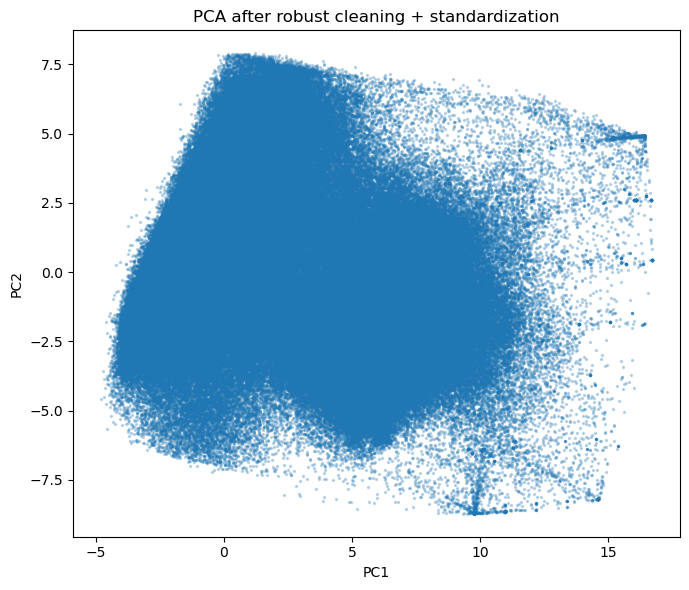

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))
plt.scatter(X2[:, 0], X2[:, 1], s=2, alpha=0.25)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA after robust cleaning + standardization")
plt.tight_layout()
plt.show()

lets test out the cleaning logic on a fuzzy method for optical then:

In [4]:
# =============================================================================
# cluster_v5_fuzzy.ipynb notebook script
# Fuzzy optical-state clustering with domain-filtered optical features
# =============================================================================

from __future__ import annotations

from pathlib import Path
import json
import pickle
import time

import joblib
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 220)


# =============================================================================
# USER SETTINGS
# =============================================================================

out_raster = Path(
    r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2025_4th_amp_phase_masked.tif"
)

out_dir = Path(r"C:\NCA_DATA\Clustering\cluster_v5_fuzzy")
out_dir.mkdir(parents=True, exist_ok=True)

sample_n = 1_000_000
random_seed = 42

RAW_BANDS = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]

# Fuzzy sweep
K_VALUES = list(range(10, 21))
M_VALUES = [1.5, 2.0]

FCM_MAX_ITER = 300
FCM_TOL = 1e-5

# Diagnostics
SIL_N = 40_000
PCA_PLOT_N = 60_000

# Conservative valid optical feature domain.
# beta0_* and energy_* are reflectance / amplitude-derived features.
# Values outside this range are treated as artifacts before clustering.
VALID_LOWER = 0.0
VALID_UPPER = 3.0

# Percentile clipping can be disabled after domain filtering.
APPLY_PERCENTILE_CLIP = False

# Only used if APPLY_PERCENTILE_CLIP = True.
BETA_LO_Q = 0.5
BETA_HI_Q = 99.5
ENERGY_LO = 0.0
ENERGY_HI_Q = 99.5

# Save all sweep-model centers but not all sweep memberships.
SAVE_ALL_MODEL_CENTERS = True


# =============================================================================
# EXPLICIT BAND MAP
# 1-based raster band indices from harmonics export
# =============================================================================

FEATURE_MAP = {
    "B2":  {"BETA0": 1,  "AMP1": 2,  "AMP2": 4,  "AMP3": 6,  "AMP4": 8},
    "B3":  {"BETA0": 11, "AMP1": 12, "AMP2": 14, "AMP3": 16, "AMP4": 18},
    "B4":  {"BETA0": 21, "AMP1": 22, "AMP2": 24, "AMP3": 26, "AMP4": 28},
    "B5":  {"BETA0": 31, "AMP1": 32, "AMP2": 34, "AMP3": 36, "AMP4": 38},
    "B6":  {"BETA0": 41, "AMP1": 42, "AMP2": 44, "AMP3": 46, "AMP4": 48},
    "B7":  {"BETA0": 51, "AMP1": 52, "AMP2": 54, "AMP3": 56, "AMP4": 58},
    "B8":  {"BETA0": 61, "AMP1": 62, "AMP2": 64, "AMP3": 66, "AMP4": 68},
    "B8A": {"BETA0": 71, "AMP1": 72, "AMP2": 74, "AMP3": 76, "AMP4": 78},
    "B11": {"BETA0": 81, "AMP1": 82, "AMP2": 84, "AMP3": 86, "AMP4": 88},
    "B12": {"BETA0": 91, "AMP1": 92, "AMP2": 94, "AMP3": 96, "AMP4": 98},
}


# =============================================================================
# DISPLAY / PRINT HELPERS
# =============================================================================

def print_section(title: str) -> None:
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)


def print_subsection(title: str) -> None:
    print("\n" + "-" * 80)
    print(title)
    print("-" * 80)


def print_matrix_quick_audit(X: np.ndarray, name: str) -> None:
    print_section(f"{name} quick matrix audit")
    print(f"shape:             {X.shape}")
    print(f"dtype:             {X.dtype}")
    print(f"finite proportion: {np.isfinite(X).mean():.8f}")
    print(f"nan count:         {np.isnan(X).sum():,}")
    print(f"inf count:         {np.isinf(X).sum():,}")
    print(f"global min:        {np.nanmin(X):.6g}")
    print(f"global max:        {np.nanmax(X):.6g}")
    print(f"global mean:       {np.nanmean(X):.6g}")
    print(f"global sd:         {np.nanstd(X):.6g}")


def show_feature_audit(
    audit_df: pd.DataFrame,
    title: str,
    n: int = 12,
) -> None:
    print_section(title)

    cols = [
        "feature", "min", "p0_1", "p1", "p50", "p99", "p99_9",
        "max", "mean", "sd"
    ]

    tmp = audit_df.copy()
    tmp["range"] = tmp["max"] - tmp["min"]

    print_subsection(f"Worst features by absolute range, top {n}")
    display(
        tmp.sort_values("range", ascending=False)[cols + ["range"]]
        .head(n)
        .reset_index(drop=True)
    )

    print_subsection(f"Most negative feature minima, top {n}")
    display(
        audit_df.sort_values("min", ascending=True)[cols]
        .head(n)
        .reset_index(drop=True)
    )

    print_subsection(f"Largest feature maxima, top {n}")
    display(
        audit_df.sort_values("max", ascending=False)[cols]
        .head(n)
        .reset_index(drop=True)
    )


def show_clip_summary(
    clip_df: pd.DataFrame,
    title: str = "Feature-aware clipping summary",
    n: int = 12,
) -> None:
    print_section(title)

    cols = [
        "feature",
        "clip_lower",
        "clip_upper",
        "n_clipped_low",
        "n_clipped_high",
        "original_min",
        "original_p1",
        "original_p50",
        "original_p99",
        "original_max",
        "clipped_min",
        "clipped_max",
    ]

    available_cols = [c for c in cols if c in clip_df.columns]

    print_subsection("All clipping thresholds")
    display(clip_df[available_cols].reset_index(drop=True))

    if "n_clipped_low" in clip_df.columns:
        print_subsection(f"Most low-clipped features, top {n}")
        display(
            clip_df.sort_values("n_clipped_low", ascending=False)[available_cols]
            .head(n)
            .reset_index(drop=True)
        )

    if "n_clipped_high" in clip_df.columns:
        print_subsection(f"Most high-clipped features, top {n}")
        display(
            clip_df.sort_values("n_clipped_high", ascending=False)[available_cols]
            .head(n)
            .reset_index(drop=True)
        )


def show_negative_value_check(
    X: np.ndarray,
    feature_names: list[str],
    title: str = "Negative-value check",
) -> pd.DataFrame:
    print_section(title)

    negative_summary = []
    for j, fname in enumerate(feature_names):
        x = X[:, j]
        negative_summary.append({
            "feature": fname,
            "n_negative": int(np.sum(x < 0)),
            "prop_negative": float(np.mean(x < 0)),
            "min": float(np.min(x)),
            "p1": float(np.percentile(x, 1)),
            "p50": float(np.percentile(x, 50)),
            "p99": float(np.percentile(x, 99)),
            "max": float(np.max(x)),
        })

    negative_df = pd.DataFrame(negative_summary)

    print_subsection("All features sorted by negative count and minimum")
    display(
        negative_df
        .sort_values(["n_negative", "min"], ascending=[False, True])
        .reset_index(drop=True)
    )

    print_subsection("Energy columns with negative values")
    display(
        negative_df[
            negative_df["feature"].str.startswith("energy_")
            & (negative_df["n_negative"] > 0)
        ]
        .reset_index(drop=True)
    )

    return negative_df


def show_scaler_summary(
    scaler_df: pd.DataFrame,
    title: str = "Scaler summary",
    n: int = 12,
) -> None:
    print_section(title)

    print_subsection(f"Largest scaling factors, top {n}")
    display(
        scaler_df.sort_values("scale", ascending=False)
        .head(n)
        .reset_index(drop=True)
    )

    print_subsection(f"Smallest scaling factors, top {n}")
    display(
        scaler_df.sort_values("scale", ascending=True)
        .head(n)
        .reset_index(drop=True)
    )


def show_pca_summary(
    pca,
    loadings: pd.DataFrame,
    title: str = "PCA summary",
    n: int = 10,
) -> None:
    print_section(title)

    print("Explained variance ratio:")
    for i, val in enumerate(pca.explained_variance_ratio_, start=1):
        print(f"  PC{i}: {val:.4f}")

    print_subsection(f"Top PC1 loadings, top {n}")
    display(
        loadings.sort_values("abs_PC1", ascending=False)
        .head(n)
        .reset_index(drop=True)
    )

    print_subsection(f"Top PC2 loadings, top {n}")
    display(
        loadings.sort_values("abs_PC2", ascending=False)
        .head(n)
        .reset_index(drop=True)
    )


def show_fcm_leaderboards(metrics_df: pd.DataFrame, n: int = 12) -> None:
    print_section("FCM sweep leaderboards")

    print_subsection(f"Best by hardened silhouette, top {n}")
    display(
        metrics_df.sort_values(
            ["silhouette_hardened", "xie_beni"],
            ascending=[False, True]
        )
        .head(n)
        .reset_index(drop=True)
    )

    print_subsection(f"Best by Xie-Beni, top {n}")
    display(
        metrics_df.sort_values("xie_beni", ascending=True)
        .head(n)
        .reset_index(drop=True)
    )

    print_subsection(f"Crispest by FPC, top {n}")
    display(
        metrics_df.sort_values("fpc", ascending=False)
        .head(n)
        .reset_index(drop=True)
    )

    print_subsection(f"Most even cluster sizes, top {n}")
    display(
        metrics_df.sort_values("cluster_size_entropy", ascending=False)
        .head(n)
        .reset_index(drop=True)
    )

    print_subsection("Compact model comparison table")
    compact_cols = [
        "m", "k",
        "silhouette_hardened",
        "xie_beni",
        "fpc",
        "partition_entropy",
        "mean_max_membership",
        "median_max_membership",
        "mean_membership_entropy",
        "cluster_size_entropy",
        "min_cluster_n",
        "max_cluster_n",
        "prop_ambiguous_0p90",
        "n_iter",
        "elapsed_seconds",
    ]

    display(
        metrics_df[compact_cols]
        .sort_values(["m", "k"])
        .reset_index(drop=True)
    )


def show_selected_membership_summary(
    membership_df: pd.DataFrame,
    selected_m: float,
    selected_k: int,
    n: int = 12,
) -> None:
    print_section(f"Selected model membership summary: m={selected_m}, k={selected_k}")

    print_subsection("Cluster sizes")
    cluster_sizes = (
        membership_df["optical_cluster_hardened"]
        .value_counts()
        .sort_index()
        .rename_axis("optical_cluster")
        .reset_index(name="n")
    )
    cluster_sizes["prop"] = cluster_sizes["n"] / cluster_sizes["n"].sum()
    display(cluster_sizes)

    print_subsection("Membership confidence variables")
    display(
        membership_df[
            ["optical_max_membership", "optical_entropy", "optical_top2_margin"]
        ].describe(percentiles=[0.01, 0.05, 0.1, 0.5, 0.9, 0.95, 0.99])
    )

    print_subsection(f"Lowest-confidence sample rows, top {n}")
    display(
        membership_df.sort_values("optical_max_membership", ascending=True)
        .head(n)
        .reset_index(drop=True)
    )

    print_subsection(f"Highest-entropy sample rows, top {n}")
    display(
        membership_df.sort_values("optical_entropy", ascending=False)
        .head(n)
        .reset_index(drop=True)
    )


# =============================================================================
# FEATURE HELPERS
# =============================================================================

def validate_feature_map(feature_map: dict) -> None:
    needed = ["BETA0", "AMP1", "AMP2", "AMP3", "AMP4"]
    for band in RAW_BANDS:
        if band not in feature_map:
            raise RuntimeError(f"Missing band in feature map: {band}")
        for component in needed:
            if component not in feature_map[band]:
                raise RuntimeError(f"Missing {component} for {band}")


def get_selected_band_indices(feature_map: dict) -> list[int]:
    selected = []
    for band in RAW_BANDS:
        selected.extend([
            feature_map[band]["BETA0"],
            feature_map[band]["AMP1"],
            feature_map[band]["AMP2"],
            feature_map[band]["AMP3"],
            feature_map[band]["AMP4"],
        ])
    return sorted(set(selected))


def build_selected_band_lookup(feature_map: dict, selected_indices: list[int]) -> dict:
    pos_map = {idx: pos for pos, idx in enumerate(selected_indices)}
    return {
        band: {component: pos_map[idx] for component, idx in feature_map[band].items()}
        for band in RAW_BANDS
    }


def build_energy_feature_names() -> list[str]:
    names = []
    for band in RAW_BANDS:
        names.extend([f"beta0_{band}", f"energy_{band}"])
    return names


def get_valid_mask(arr, src) -> np.ndarray:
    valid = (~np.any(arr.mask, axis=0)) & np.all(np.isfinite(arr.data), axis=0)

    nodata = src.nodata
    if nodata is not None:
        valid &= ~np.any(arr.data == nodata, axis=0)

    return valid


def extract_energy_features_from_block(block: np.ndarray, lookup: dict) -> np.ndarray:
    energy_cols = []

    for band in RAW_BANDS:
        beta0 = block[lookup[band]["BETA0"]].reshape(-1)
        a1 = block[lookup[band]["AMP1"]].reshape(-1)
        a2 = block[lookup[band]["AMP2"]].reshape(-1)
        a3 = block[lookup[band]["AMP3"]].reshape(-1)
        a4 = block[lookup[band]["AMP4"]].reshape(-1)

        energy = np.sqrt(a1**2 + a2**2 + a3**2 + a4**2)
        energy_cols.extend([beta0, energy])

    return np.column_stack(energy_cols).astype(np.float32)


# =============================================================================
# SAMPLING
# =============================================================================

def sample_energy_matrix_from_raster(
    raster_path: Path,
    sample_n: int,
    random_seed: int,
):
    validate_feature_map(FEATURE_MAP)

    selected = get_selected_band_indices(FEATURE_MAP)
    lookup = build_selected_band_lookup(FEATURE_MAP, selected)
    feature_names = build_energy_feature_names()

    with rasterio.open(raster_path) as src:
        window_infos = []
        total_valid = 0

        print_section("Scanning valid pixels")
        for _, window in src.block_windows(1):
            arr = src.read(indexes=selected, window=window, masked=True)
            valid = get_valid_mask(arr, src)
            n_valid = int(valid.sum())

            if n_valid > 0:
                window_infos.append((window, valid, n_valid))
                total_valid += n_valid

        print(f"Total valid pixels: {total_valid:,}")
        print(f"Valid windows:       {len(window_infos):,}")

        if total_valid == 0:
            raise RuntimeError("No valid pixels found.")

        rng = np.random.default_rng(random_seed)

        X_parts = []
        xy_parts = []
        rc_parts = []

        print_section("Sampling raster blocks")
        for i, (window, valid, n_valid) in enumerate(window_infos, start=1):
            n_take = int(sample_n * (n_valid / total_valid))
            if n_take == 0:
                continue

            arr = src.read(indexes=selected, window=window)
            block = arr.astype(np.float32)

            rows, cols = np.where(valid)
            if n_take > len(rows):
                n_take = len(rows)

            idx = rng.choice(len(rows), size=n_take, replace=False)

            rr = rows[idx]
            cc = cols[idx]

            global_rows = rr + int(window.row_off)
            global_cols = cc + int(window.col_off)

            flat = rr * block.shape[2] + cc

            Xe = extract_energy_features_from_block(block, lookup)
            X_parts.append(Xe[flat])

            xs, ys = rasterio.transform.xy(
                src.transform,
                global_rows,
                global_cols,
                offset="center",
            )

            xy_parts.append(np.column_stack([xs, ys]).astype(np.float64))
            rc_parts.append(np.column_stack([global_rows, global_cols]).astype(np.int32))

            if i % 100 == 0:
                current_n = sum(part.shape[0] for part in X_parts)
                print(f"  processed windows: {i:,} / {len(window_infos):,} | sampled rows so far: {current_n:,}")

        X = np.vstack(X_parts).astype(np.float32)
        xy = np.vstack(xy_parts)
        rc = np.vstack(rc_parts)

    sample_df = pd.DataFrame({
        "x": xy[:, 0],
        "y": xy[:, 1],
        "row": rc[:, 0],
        "col": rc[:, 1],
    })

    print(f"Sampled matrix shape: {X.shape}")

    return X, sample_df, feature_names


# =============================================================================
# CLEANING, CLIPPING, AUDITING
# =============================================================================

def make_valid_row_mask(
    X: np.ndarray,
    feature_names: list[str],
    lower: float = VALID_LOWER,
    upper: float = VALID_UPPER,
) -> np.ndarray:
    """
    Conservative optical-domain validity screen.

    Removes rows where any selected optical feature falls outside [lower, upper].
    For this feature set, beta0 values are reflectance-like intercepts and
    energy values are amplitude-derived magnitudes. Values outside this range
    are treated as artifacts rather than ecological extremes.
    """
    valid = np.all(np.isfinite(X), axis=1)
    valid &= ~np.any(X < lower, axis=1)
    valid &= ~np.any(X > upper, axis=1)

    return valid


def feature_aware_clip_energy(
    X: np.ndarray,
    feature_names: list[str],
    out_dir: Path,
    name: str = "energy",
):
    Xc = X.copy().astype(np.float32)

    rows = []

    for j, fname in enumerate(feature_names):
        x = Xc[:, j]

        if fname.startswith("beta0_"):
            lo = np.percentile(x, BETA_LO_Q)
            hi = np.percentile(x, BETA_HI_Q)
            clipped = np.clip(x, lo, hi)

        elif fname.startswith("energy_"):
            lo = ENERGY_LO
            hi = np.percentile(x, ENERGY_HI_Q)
            clipped = np.clip(x, lo, hi)

        else:
            raise ValueError(f"Unrecognized feature name: {fname}")

        n_low = int(np.sum(x < lo))
        n_high = int(np.sum(x > hi))

        rows.append({
            "feature": fname,
            "clip_lower": float(lo),
            "clip_upper": float(hi),
            "n_clipped_low": n_low,
            "n_clipped_high": n_high,
            "original_min": float(np.min(x)),
            "original_p0_1": float(np.percentile(x, 0.1)),
            "original_p1": float(np.percentile(x, 1)),
            "original_p50": float(np.percentile(x, 50)),
            "original_p99": float(np.percentile(x, 99)),
            "original_p99_9": float(np.percentile(x, 99.9)),
            "original_max": float(np.max(x)),
            "clipped_min": float(np.min(clipped)),
            "clipped_max": float(np.max(clipped)),
        })

        Xc[:, j] = clipped.astype(np.float32)

    clip_df = pd.DataFrame(rows)
    clip_df.to_csv(out_dir / f"{name}_clip_thresholds.csv", index=False)

    return Xc, clip_df


def audit_matrix(X: np.ndarray, feature_names: list[str], out_path: Path) -> pd.DataFrame:
    rows = []

    for j, fname in enumerate(feature_names):
        x = X[:, j]

        rows.append({
            "feature": fname,
            "n": len(x),
            "n_finite": int(np.isfinite(x).sum()),
            "n_nan": int(np.isnan(x).sum()),
            "n_inf": int(np.isinf(x).sum()),
            "min": float(np.nanmin(x)),
            "p0_1": float(np.nanpercentile(x, 0.1)),
            "p1": float(np.nanpercentile(x, 1)),
            "p50": float(np.nanpercentile(x, 50)),
            "p99": float(np.nanpercentile(x, 99)),
            "p99_9": float(np.nanpercentile(x, 99.9)),
            "max": float(np.nanmax(x)),
            "mean": float(np.nanmean(x)),
            "sd": float(np.nanstd(x)),
        })

    df = pd.DataFrame(rows)
    df.to_csv(out_path, index=False)
    return df


# =============================================================================
# FUZZY C-MEANS
# =============================================================================

def init_membership(n: int, k: int, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    U = rng.random((n, k)).astype(np.float32)
    U /= U.sum(axis=1, keepdims=True)
    return U


def fuzzy_cmeans(
    X: np.ndarray,
    k: int,
    m: float,
    max_iter: int,
    tol: float,
    seed: int,
    verbose: bool = False,
):
    if m <= 1.0:
        raise ValueError("FCM requires m > 1.0")

    X = X.astype(np.float32, copy=False)
    n = X.shape[0]
    eps = 1e-12

    U = init_membership(n, k, seed)
    jm = []

    for it in range(max_iter):
        U_old = U.copy()

        Um = U ** m
        centers = (Um.T @ X) / (Um.sum(axis=0)[:, None] + eps)
        centers = centers.astype(np.float32)

        D = cdist(X, centers, metric="euclidean").astype(np.float32)
        D = np.fmax(D, eps)

        power = -2.0 / (m - 1.0)
        tmp = D ** power
        U = tmp / tmp.sum(axis=1, keepdims=True)
        U = U.astype(np.float32)

        obj = float(np.sum((U ** m) * (D ** 2)))
        jm.append(obj)

        max_delta = float(np.max(np.abs(U - U_old)))

        if verbose and it % 10 == 0:
            print(f"      iter={it:03d} | obj={obj:,.3f} | max_delta={max_delta:.6g}")

        if max_delta < tol:
            if verbose:
                print(f"      converged at iter={it}")
            break

    return centers, U, np.array(jm, dtype=np.float64)


def predict_fcm_membership(X: np.ndarray, centers: np.ndarray, m: float) -> np.ndarray:
    eps = 1e-12
    D = cdist(X, centers, metric="euclidean").astype(np.float32)
    D = np.fmax(D, eps)

    power = -2.0 / (m - 1.0)
    tmp = D ** power
    U = tmp / tmp.sum(axis=1, keepdims=True)
    return U.astype(np.float32)


def fuzzy_partition_coefficient(U: np.ndarray) -> float:
    return float(np.sum(U ** 2) / U.shape[0])


def partition_entropy(U: np.ndarray) -> float:
    eps = 1e-12
    return float(-np.sum(U * np.log(U + eps)) / U.shape[0])


def xie_beni_index(X: np.ndarray, centers: np.ndarray, U: np.ndarray, m: float) -> float:
    eps = 1e-12
    D = cdist(X, centers, metric="euclidean").astype(np.float32)
    num = np.sum((U ** m) * (D ** 2))

    center_dist = cdist(centers, centers, metric="euclidean")
    np.fill_diagonal(center_dist, np.inf)
    min_sep_sq = np.min(center_dist) ** 2

    return float(num / (X.shape[0] * (min_sep_sq + eps)))


def assignment_margin_stats(X: np.ndarray, centers: np.ndarray) -> dict:
    D = cdist(X, centers, metric="euclidean").astype(np.float32)
    two = np.partition(D, kth=1, axis=1)[:, :2]
    two.sort(axis=1)

    d1 = two[:, 0]
    d2 = two[:, 1]

    denom = np.where(d2 <= 1e-12, 1e-12, d2)
    margin = (d2 - d1) / denom
    ratio = d1 / denom

    return {
        "margin_mean": float(np.mean(margin)),
        "margin_sd": float(np.std(margin)),
        "margin_median": float(np.median(margin)),
        "d1_over_d2_mean": float(np.mean(ratio)),
        "d1_over_d2_median": float(np.median(ratio)),
        "prop_ambiguous_0p90": float(np.mean(ratio > 0.90)),
        "prop_ambiguous_0p95": float(np.mean(ratio > 0.95)),
    }


def membership_summary(U: np.ndarray) -> dict:
    max_u = np.max(U, axis=1)
    sorted_u = np.sort(U, axis=1)
    top1 = sorted_u[:, -1]
    top2 = sorted_u[:, -2] if U.shape[1] > 1 else np.zeros_like(top1)
    top2_margin = top1 - top2

    eps = 1e-12
    entropy = -np.sum(U * np.log(U + eps), axis=1)

    return {
        "mean_max_membership": float(np.mean(max_u)),
        "median_max_membership": float(np.median(max_u)),
        "p10_max_membership": float(np.percentile(max_u, 10)),
        "p90_max_membership": float(np.percentile(max_u, 90)),
        "mean_top2_membership_margin": float(np.mean(top2_margin)),
        "median_top2_membership_margin": float(np.median(top2_margin)),
        "mean_membership_entropy": float(np.mean(entropy)),
        "median_membership_entropy": float(np.median(entropy)),
    }


def cluster_size_summary(labels: np.ndarray, k: int) -> dict:
    counts = np.bincount(labels, minlength=k + 1)[1:]
    props = counts / counts.sum()

    eps = 1e-12
    entropy = -np.sum(props * np.log(props + eps)) / np.log(k)

    return {
        "min_cluster_n": int(np.min(counts)),
        "max_cluster_n": int(np.max(counts)),
        "min_cluster_prop": float(np.min(props)),
        "max_cluster_prop": float(np.max(props)),
        "cluster_size_entropy": float(entropy),
    }


# =============================================================================
# PLOTTING
# =============================================================================

def save_metric_plot(df: pd.DataFrame, metric: str, out_path: Path, title: str) -> None:
    plt.figure(figsize=(8, 5))
    for m in sorted(df["m"].unique()):
        sub = df[df["m"] == m].sort_values("k")
        plt.plot(sub["k"], sub[metric], marker="o", label=f"m={m}")
    plt.xlabel("k")
    plt.ylabel(metric)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()


def save_pca_clean_plot(Xz: np.ndarray, out_path: Path, n_plot: int, seed: int):
    rng = np.random.default_rng(seed)
    idx = rng.choice(Xz.shape[0], size=min(n_plot, Xz.shape[0]), replace=False)

    pca = PCA(n_components=2, random_state=seed)
    X2 = pca.fit_transform(Xz[idx])

    plt.figure(figsize=(7, 6))
    plt.scatter(X2[:, 0], X2[:, 1], s=2, alpha=0.25)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA after domain filtering + standardization")
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()

    loadings = pd.DataFrame(
        pca.components_.T,
        columns=["PC1_loading", "PC2_loading"],
    )

    return pca, loadings


def save_selected_pca_plots(
    Xz: np.ndarray,
    labels: np.ndarray,
    max_u: np.ndarray,
    entropy: np.ndarray,
    centers: np.ndarray,
    out_dir: Path,
    m: float,
    k: int,
    n_plot: int,
    seed: int,
):
    rng = np.random.default_rng(seed)
    idx = rng.choice(Xz.shape[0], size=min(n_plot, Xz.shape[0]), replace=False)

    pca = PCA(n_components=2, random_state=seed)
    X2 = pca.fit_transform(Xz[idx])
    C2 = pca.transform(centers)

    plt.figure(figsize=(8, 6))
    plt.scatter(X2[:, 0], X2[:, 1], c=labels[idx], s=2, alpha=0.35, cmap="tab20")
    plt.scatter(C2[:, 0], C2[:, 1], c="black", s=80, marker="x")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"Selected FCM hardened labels, m={m}, k={k}")
    plt.tight_layout()
    plt.savefig(out_dir / f"selected_pca_hardened_m{str(m).replace('.', 'p')}_k{k}.png", dpi=200)
    plt.close()

    plt.figure(figsize=(8, 6))
    plt.scatter(X2[:, 0], X2[:, 1], c=max_u[idx], s=2, alpha=0.35)
    plt.colorbar(label="max membership")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"Selected FCM max membership, m={m}, k={k}")
    plt.tight_layout()
    plt.savefig(out_dir / f"selected_pca_max_membership_m{str(m).replace('.', 'p')}_k{k}.png", dpi=200)
    plt.close()

    plt.figure(figsize=(8, 6))
    plt.scatter(X2[:, 0], X2[:, 1], c=entropy[idx], s=2, alpha=0.35)
    plt.colorbar(label="membership entropy")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"Selected FCM membership entropy, m={m}, k={k}")
    plt.tight_layout()
    plt.savefig(out_dir / f"selected_pca_entropy_m{str(m).replace('.', 'p')}_k{k}.png", dpi=200)
    plt.close()


# =============================================================================
# STEP 1 — SAMPLE OPTICAL ENERGY FEATURES
# =============================================================================

start = time.time()

run_settings = {
    "out_raster": str(out_raster),
    "out_dir": str(out_dir),
    "sample_n": sample_n,
    "random_seed": random_seed,
    "raw_bands": RAW_BANDS,
    "k_values": K_VALUES,
    "m_values": M_VALUES,
    "fcm_max_iter": FCM_MAX_ITER,
    "fcm_tol": FCM_TOL,
    "valid_lower": VALID_LOWER,
    "valid_upper": VALID_UPPER,
    "apply_percentile_clip": APPLY_PERCENTILE_CLIP,
    "beta_lo_q": BETA_LO_Q if APPLY_PERCENTILE_CLIP else None,
    "beta_hi_q": BETA_HI_Q if APPLY_PERCENTILE_CLIP else None,
    "energy_lo": ENERGY_LO if APPLY_PERCENTILE_CLIP else None,
    "energy_hi_q": ENERGY_HI_Q if APPLY_PERCENTILE_CLIP else None,
}

with open(out_dir / "cluster_v5_fuzzy_settings.json", "w") as f:
    json.dump(run_settings, f, indent=2)

X_raw, sample_df, feature_names = sample_energy_matrix_from_raster(
    out_raster,
    sample_n=sample_n,
    random_seed=random_seed,
)

pd.Series(feature_names).to_csv(
    out_dir / "energy_feature_names.csv",
    index=False,
    header=["feature"],
)

sample_df.to_csv(out_dir / "sample_xy_row_col.csv", index=False)
np.save(out_dir / "X_energy_1M_raw.npy", X_raw)

raw_audit = audit_matrix(
    X_raw,
    feature_names,
    out_dir / "energy_raw_feature_audit.csv",
)

print_matrix_quick_audit(X_raw, "X_raw")
show_feature_audit(raw_audit, "Raw feature audit")


# =============================================================================
# STEP 2 — DOMAIN-FILTER BAD ROWS
# =============================================================================

valid_row = make_valid_row_mask(
    X_raw,
    feature_names,
    lower=VALID_LOWER,
    upper=VALID_UPPER,
)

print_section("Domain-filter row removal summary")
print(f"Valid feature domain: [{VALID_LOWER}, {VALID_UPPER}]")
print(f"Original rows: {len(X_raw):,}")
print(f"Valid rows:    {valid_row.sum():,}")
print(f"Removed rows:  {(~valid_row).sum():,}")
print(f"Removed prop:  {(~valid_row).mean():.8f}")

np.save(out_dir / "energy_valid_row_mask.npy", valid_row)

X_clean = X_raw[valid_row].astype(np.float32)
sample_clean = sample_df.loc[valid_row].reset_index(drop=True)

sample_clean.to_csv(out_dir / "sample_xy_row_col_clean.csv", index=False)
np.save(out_dir / "X_energy_1M_domain_filtered.npy", X_clean)

clean_audit = audit_matrix(
    X_clean,
    feature_names,
    out_dir / "energy_domain_filtered_feature_audit.csv",
)

print_matrix_quick_audit(X_clean, "X_clean domain-filtered")
show_feature_audit(clean_audit, "Domain-filtered feature audit")

negative_df = show_negative_value_check(
    X_clean,
    feature_names,
    "Negative-value check after domain filtering"
)
negative_df.to_csv(out_dir / "energy_negative_value_check_after_domain_filter.csv", index=False)


# =============================================================================
# STEP 3 — OPTIONAL FEATURE-AWARE CLIPPING
# =============================================================================

if APPLY_PERCENTILE_CLIP:
    print_section("Feature-aware clipping settings")
    print(f"beta0 clip:  p{BETA_LO_Q}–p{BETA_HI_Q}")
    print(f"energy clip: {ENERGY_LO}–p{ENERGY_HI_Q}")

    X_model, clip_df = feature_aware_clip_energy(
        X_clean,
        feature_names,
        out_dir=out_dir,
        name="energy",
    )

    np.save(out_dir / "X_energy_1M_model.npy", X_model)

    model_audit = audit_matrix(
        X_model,
        feature_names,
        out_dir / "energy_model_feature_audit.csv",
    )

    print_matrix_quick_audit(X_model, "X_model clipped")
    show_clip_summary(clip_df)
    show_feature_audit(model_audit, "Model feature audit after clipping")

else:
    print_section("Skipping percentile clipping")
    print("Using domain-filtered optical features directly for standardization and FCM.")
    print(f"Valid feature domain: [{VALID_LOWER}, {VALID_UPPER}]")

    X_model = X_clean.copy().astype(np.float32)

    clip_df = pd.DataFrame({
        "feature": feature_names,
        "clip_lower": np.nan,
        "clip_upper": np.nan,
        "n_clipped_low": 0,
        "n_clipped_high": 0,
        "note": "No percentile clipping applied; valid-domain filter used instead.",
    })

    clip_df.to_csv(out_dir / "energy_clip_thresholds.csv", index=False)

    np.save(out_dir / "X_energy_1M_model.npy", X_model)

    model_audit = audit_matrix(
        X_model,
        feature_names,
        out_dir / "energy_model_feature_audit.csv",
    )

    print_matrix_quick_audit(X_model, "X_model domain-filtered")
    show_feature_audit(model_audit, "Model feature audit without percentile clipping")


# =============================================================================
# STEP 4 — STANDARDIZE AND PCA SANITY CHECK
# =============================================================================

scaler = StandardScaler()
Xz = scaler.fit_transform(X_model).astype(np.float32)

joblib.dump(scaler, out_dir / "energy_model_scaler.joblib")
np.save(out_dir / "X_energy_1M_model_standardized.npy", Xz)

scaler_df = pd.DataFrame({
    "feature": feature_names,
    "mean": scaler.mean_,
    "scale": scaler.scale_,
})
scaler_df.to_csv(out_dir / "energy_model_scaler_parameters.csv", index=False)

print_matrix_quick_audit(Xz, "Xz standardized")
show_scaler_summary(scaler_df)

pca, loadings = save_pca_clean_plot(
    Xz,
    out_dir / "pca_after_domain_filtering_standardization.png",
    n_plot=PCA_PLOT_N,
    seed=random_seed,
)

loadings.insert(0, "feature", feature_names)
loadings["abs_PC1"] = loadings["PC1_loading"].abs()
loadings["abs_PC2"] = loadings["PC2_loading"].abs()
loadings.to_csv(out_dir / "pca_loadings_domain_filtered.csv", index=False)

show_pca_summary(pca, loadings)


# =============================================================================
# STEP 5 — PREPARE SILHOUETTE SUBSET
# =============================================================================

rng = np.random.default_rng(random_seed)

if Xz.shape[0] > SIL_N:
    sil_idx = rng.choice(Xz.shape[0], size=SIL_N, replace=False)
    X_sil = Xz[sil_idx]
else:
    sil_idx = np.arange(Xz.shape[0])
    X_sil = Xz

np.save(out_dir / "silhouette_subset_indices.npy", sil_idx)

print_section("Silhouette subset")
print(f"Xz shape:      {Xz.shape}")
print(f"X_sil shape:   {X_sil.shape}")
print(f"SIL_N setting: {SIL_N:,}")


# =============================================================================
# STEP 6 — FUZZY C-MEANS SWEEP
# =============================================================================

metrics_rows = []
centers_dir = out_dir / "model_centers"
centers_dir.mkdir(exist_ok=True)

print_section("Starting fuzzy c-means sweep")
print(f"K_VALUES:      {K_VALUES}")
print(f"M_VALUES:      {M_VALUES}")
print(f"FCM_MAX_ITER:  {FCM_MAX_ITER}")
print(f"FCM_TOL:       {FCM_TOL}")

for m in M_VALUES:
    print_section(f"Fuzzy sweep: m = {m}")

    for k in K_VALUES:
        model_start = time.time()
        print(f"Running FCM: m={m}, k={k}")

        centers, U, jm = fuzzy_cmeans(
            Xz,
            k=k,
            m=m,
            max_iter=FCM_MAX_ITER,
            tol=FCM_TOL,
            seed=random_seed + int(k * 100 + m * 10),
            verbose=False,
        )

        hard_labels = np.argmax(U, axis=1) + 1
        max_u = np.max(U, axis=1)

        fpc = fuzzy_partition_coefficient(U)
        pe = partition_entropy(U)
        xb = xie_beni_index(Xz, centers, U, m)

        sil = silhouette_score(
            X_sil,
            hard_labels[sil_idx],
            metric="euclidean",
        )

        ch = calinski_harabasz_score(Xz, hard_labels)

        margin_stats = assignment_margin_stats(Xz, centers)
        mem_stats = membership_summary(U)
        size_stats = cluster_size_summary(hard_labels, k)

        elapsed = time.time() - model_start

        row = {
            "method": "fcm",
            "m": float(m),
            "k": int(k),
            "fpc": float(fpc),
            "partition_entropy": float(pe),
            "xie_beni": float(xb),
            "silhouette_hardened": float(sil),
            "calinski_harabasz_hardened": float(ch),
            "objective_final": float(jm[-1]),
            "objective_initial": float(jm[0]),
            "n_iter": int(len(jm)),
            "elapsed_seconds": float(elapsed),
            **margin_stats,
            **mem_stats,
            **size_stats,
        }

        metrics_rows.append(row)

        print(
            f"finished m={m}, k={k} | "
            f"sil={sil:.4f}, XB={xb:.4f}, FPC={fpc:.4f}, "
            f"mean maxU={mem_stats['mean_max_membership']:.4f}, "
            f"size entropy={size_stats['cluster_size_entropy']:.4f}, "
            f"time={elapsed/60:.2f} min"
        )

        if SAVE_ALL_MODEL_CENTERS:
            stem = f"fcm_m{str(m).replace('.', 'p')}_k{k}"
            np.save(centers_dir / f"{stem}_centers_standardized.npy", centers)
            np.save(centers_dir / f"{stem}_objective.npy", jm)

            center_df = pd.DataFrame(centers, columns=feature_names)
            center_df.insert(0, "optical_cluster", np.arange(1, k + 1))
            center_df.insert(0, "k", k)
            center_df.insert(0, "m", m)
            center_df.to_csv(
                centers_dir / f"{stem}_centers_standardized.csv",
                index=False,
            )

        del U

        metrics_df = pd.DataFrame(metrics_rows)
        metrics_df.to_csv(out_dir / "fcm_sweep_metrics_in_progress.csv", index=False)

metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv(out_dir / "fcm_sweep_metrics.csv", index=False)

show_fcm_leaderboards(metrics_df)


# =============================================================================
# STEP 7 — METRIC PLOTS
# =============================================================================

save_metric_plot(
    metrics_df,
    "fpc",
    out_dir / "fcm_metric_fpc.png",
    "Optical FCM: FPC, higher = crisper",
)

save_metric_plot(
    metrics_df,
    "partition_entropy",
    out_dir / "fcm_metric_partition_entropy.png",
    "Optical FCM: partition entropy, lower = crisper",
)

save_metric_plot(
    metrics_df,
    "xie_beni",
    out_dir / "fcm_metric_xie_beni.png",
    "Optical FCM: Xie-Beni, lower = compact/separated",
)

save_metric_plot(
    metrics_df,
    "silhouette_hardened",
    out_dir / "fcm_metric_silhouette_hardened.png",
    "Optical FCM: hardened silhouette",
)

save_metric_plot(
    metrics_df,
    "mean_max_membership",
    out_dir / "fcm_metric_mean_max_membership.png",
    "Optical FCM: mean maximum membership",
)

save_metric_plot(
    metrics_df,
    "cluster_size_entropy",
    out_dir / "fcm_metric_cluster_size_entropy.png",
    "Optical FCM: cluster size entropy",
)

print_section("Metric plots written")
print(out_dir)


# =============================================================================
# STEP 8 — SELECT PROVISIONAL MODEL
# =============================================================================

selected_row = (
    metrics_df
    .sort_values(
        ["silhouette_hardened", "xie_beni", "cluster_size_entropy", "mean_max_membership"],
        ascending=[False, True, False, False],
    )
    .iloc[0]
)

selected_m = float(selected_row["m"])
selected_k = int(selected_row["k"])

print_section("Provisional selected model")
print(selected_row.to_string())


# =============================================================================
# STEP 9 — REFIT SELECTED MODEL AND SAVE MEMBERSHIPS
# =============================================================================

print_section(f"Refitting selected model: m={selected_m}, k={selected_k}")

centers, U, jm = fuzzy_cmeans(
    Xz,
    k=selected_k,
    m=selected_m,
    max_iter=FCM_MAX_ITER,
    tol=FCM_TOL,
    seed=random_seed + int(selected_k * 100 + selected_m * 10),
    verbose=True,
)

hard_labels = np.argmax(U, axis=1) + 1
max_u = np.max(U, axis=1)

eps = 1e-12
entropy = -np.sum(U * np.log(U + eps), axis=1)

sorted_u = np.sort(U, axis=1)
top1 = sorted_u[:, -1]
top2 = sorted_u[:, -2]
top2_margin = top1 - top2

selected_stem = f"selected_fcm_m{str(selected_m).replace('.', 'p')}_k{selected_k}"

center_df = pd.DataFrame(centers, columns=feature_names)
center_df.insert(0, "optical_cluster", np.arange(1, selected_k + 1))
center_df.insert(0, "k", selected_k)
center_df.insert(0, "m", selected_m)
center_df.to_csv(out_dir / f"{selected_stem}_centers_standardized.csv", index=False)

np.save(out_dir / f"{selected_stem}_centers_standardized.npy", centers)
np.save(out_dir / f"{selected_stem}_membership.npy", U)
np.save(out_dir / f"{selected_stem}_hardened_labels.npy", hard_labels)
np.save(out_dir / f"{selected_stem}_objective.npy", jm)

membership_df = sample_clean.copy()
membership_df["optical_cluster_hardened"] = hard_labels
membership_df["optical_max_membership"] = max_u
membership_df["optical_entropy"] = entropy
membership_df["optical_top2_margin"] = top2_margin

for j in range(selected_k):
    membership_df[f"optical_u_{j + 1:02d}"] = U[:, j]

membership_df.to_csv(
    out_dir / f"{selected_stem}_sample_memberships.csv",
    index=False,
)

with open(out_dir / f"{selected_stem}_model.pkl", "wb") as f:
    pickle.dump(
        {
            "m": selected_m,
            "k": selected_k,
            "feature_names": feature_names,
            "centers_standardized": centers,
            "scaler": scaler,
            "clip_thresholds": clip_df,
            "settings": run_settings,
        },
        f,
    )

selected_summary = {
    "selected_m": selected_m,
    "selected_k": selected_k,
    "selection_rule": (
        "highest hardened silhouette, then lowest Xie-Beni, "
        "then highest cluster-size entropy, then highest mean max membership"
    ),
    "selected_metrics": selected_row.to_dict(),
    "n_clean_sample": int(Xz.shape[0]),
    "runtime_seconds": float(time.time() - start),
}

with open(out_dir / "selected_model_summary.json", "w") as f:
    json.dump(selected_summary, f, indent=2)

print_section("Selected model summary")
print(json.dumps(selected_summary, indent=2))

show_selected_membership_summary(
    membership_df,
    selected_m=selected_m,
    selected_k=selected_k,
)


# =============================================================================
# STEP 10 — SELECTED-MODEL PCA PLOTS
# =============================================================================

save_selected_pca_plots(
    Xz,
    hard_labels,
    max_u,
    entropy,
    centers,
    out_dir=out_dir,
    m=selected_m,
    k=selected_k,
    n_plot=PCA_PLOT_N,
    seed=random_seed,
)

print_section("Selected-model plots written")
print(out_dir)


# =============================================================================
# OUTPUT SUMMARY
# =============================================================================

print_section("Core outputs")
for p in [
    out_dir / "X_energy_1M_raw.npy",
    out_dir / "X_energy_1M_domain_filtered.npy",
    out_dir / "X_energy_1M_model.npy",
    out_dir / "X_energy_1M_model_standardized.npy",
    out_dir / "energy_feature_names.csv",
    out_dir / "energy_raw_feature_audit.csv",
    out_dir / "energy_domain_filtered_feature_audit.csv",
    out_dir / "energy_model_feature_audit.csv",
    out_dir / "energy_clip_thresholds.csv",
    out_dir / "energy_negative_value_check_after_domain_filter.csv",
    out_dir / "energy_model_scaler.joblib",
    out_dir / "energy_model_scaler_parameters.csv",
    out_dir / "pca_after_domain_filtering_standardization.png",
    out_dir / "pca_loadings_domain_filtered.csv",
    out_dir / "fcm_sweep_metrics.csv",
    out_dir / "selected_model_summary.json",
    out_dir / f"{selected_stem}_model.pkl",
    out_dir / f"{selected_stem}_sample_memberships.csv",
]:
    print(p)

print(f"\nRuntime so far: {(time.time() - start) / 60:.2f} minutes")


Scanning valid pixels
Total valid pixels: 43,510,891
Valid windows:       757

Sampling raster blocks
  processed windows: 100 / 757 | sampled rows so far: 127,874
  processed windows: 200 / 757 | sampled rows so far: 264,767
  processed windows: 300 / 757 | sampled rows so far: 398,962
  processed windows: 400 / 757 | sampled rows so far: 535,598
  processed windows: 500 / 757 | sampled rows so far: 674,667
  processed windows: 600 / 757 | sampled rows so far: 809,274
  processed windows: 700 / 757 | sampled rows so far: 934,979
Sampled matrix shape: (999668, 20)

X_raw quick matrix audit
shape:             (999668, 20)
dtype:             float32
finite proportion: 1.00000000
nan count:         0
inf count:         0
global min:        -1.45405e+06
global max:        2.64904e+06
global mean:       0.757087
global sd:         917.336

Raw feature audit

--------------------------------------------------------------------------------
Worst features by absolute range, top 12
-----------

,feature,min,p0_1,p1,p50,p99,p99_9,max,mean,sd,range
0,energy_B7,3.211449e-03,0.007773,0.010991,0.032575,0.239263,25.486845,2.649040e+06,3.636149,2651.940430,2.649040e+06
1,energy_B6,3.386612e-03,0.007403,0.010336,0.030314,0.184470,24.604691,1.654333e+06,2.627388,1658.884155,1.654333e+06
2,beta0_B7,-1.454052e+06,-1.504382,0.136791,0.193296,0.411154,2.303155,2.512935e+04,-1.209364,1455.563599,1.479181e+06
3,energy_B8,2.659621e-03,0.007564,0.010742,0.032187,0.236358,26.606565,1.061640e+06,2.157028,1070.161499,1.061640e+06
4,beta0_B6,-9.079674e+05,-1.447423,0.127366,0.181847,0.351479,2.462241,1.865288e+04,-0.714918,910.313171,9.266203e+05
5,energy_B8A,3.109937e-03,0.008311,0.011865,0.034891,0.238418,26.584898,7.842390e+05,1.766942,792.278992,7.842390e+05
6,energy_B5,3.039799e-03,0.009113,0.012674,0.028610,0.151970,21.926516,7.471889e+05,1.596111,753.323242,7.471889e+05
7,energy_B2,2.420346e-03,0.005342,0.007684,0.017663,0.086212,15.570940,6.416628e+05,1.240257,644.980042,6.416627e+05
8,beta0_B8,-5.827902e+05,-1.589649,0.144748,0.204964,0.431041,2.481688,2.504213e+04,-0.378251,587.211304,6.078324e+05
9,energy_B3,2.187931e-03,0.006971,0.009656,0.020991,0.101183,18.232323,5.270626e+05,1.226975,532.302124,5.270626e+05



--------------------------------------------------------------------------------
Most negative feature minima, top 12
--------------------------------------------------------------------------------


,feature,min,p0_1,p1,p50,p99,p99_9,max,mean,sd
0,beta0_B7,-1.454052e+06,-1.504382,0.136791,0.193296,0.411154,2.303155,25129.347656,-1.209364,1455.563599
1,beta0_B6,-9.079674e+05,-1.447423,0.127366,0.181847,0.351479,2.462241,18652.884766,-0.714918,910.313171
2,beta0_B8,-5.827902e+05,-1.589649,0.144748,0.204964,0.431041,2.481688,25042.134766,-0.378251,587.211304
3,beta0_B8A,-4.304602e+05,-1.593354,0.152424,0.211545,0.435996,2.367805,15065.259766,-0.196472,434.592285
4,beta0_B5,-4.101850e+05,-1.455080,0.107678,0.155429,0.249351,1.899561,16975.103516,-0.250381,413.319824
5,beta0_B2,-3.522928e+05,-1.052175,0.043690,0.077906,0.138487,1.536376,16744.064453,-0.236524,353.997925
6,beta0_B3,-2.893718e+05,-1.143258,0.066555,0.100986,0.176817,1.790732,12414.501953,-0.167437,292.053528
7,beta0_B11,-1.391588e+05,-1.821914,0.191478,0.283270,0.362034,2.798619,15037.252930,0.218410,148.818542
8,beta0_B12,-2.634833e+04,-1.997802,0.133175,0.219282,0.316601,2.627687,69606.179688,0.311609,90.105675
9,beta0_B4,-1.687681e+04,-1.451350,0.067653,0.127197,0.220633,1.932871,24101.193359,0.204946,48.933922



--------------------------------------------------------------------------------
Largest feature maxima, top 12
--------------------------------------------------------------------------------


...


--------------------------------------------------------------------------------
Lowest-confidence sample rows, top 12
--------------------------------------------------------------------------------


,x,y,row,col,optical_cluster_hardened,optical_max_membership,optical_entropy,optical_top2_margin,optical_u_01,optical_u_02,optical_u_03,optical_u_04,optical_u_05,optical_u_06,optical_u_07,optical_u_08,optical_u_09,optical_u_10
0,568365.0,4766815.0,4859,4062,5,0.106678,2.301829,0.002126,0.097537,0.094643,0.104552,0.095598,0.106678,0.104475,0.101327,0.098951,0.097020,0.099220
1,528435.0,4791925.0,2348,69,5,0.106710,2.301765,0.001308,0.097189,0.094405,0.105401,0.095292,0.106710,0.103960,0.100892,0.100598,0.096719,0.098835
2,613375.0,4759745.0,5566,8563,5,0.106989,2.301769,0.001953,0.097725,0.094439,0.104268,0.095584,0.106989,0.105037,0.101552,0.098133,0.096888,0.099384
3,559515.0,4772075.0,4333,3177,5,0.107011,2.301692,0.001298,0.097144,0.094192,0.105713,0.095159,0.107011,0.104106,0.100800,0.100689,0.096452,0.098732
4,550885.0,4779005.0,3640,2314,5,0.107049,2.301717,0.001546,0.097662,0.094374,0.104003,0.095471,0.107049,0.105503,0.102047,0.097149,0.097119,0.099622
5,550765.0,4782405.0,3300,2302,5,0.107082,2.301669,0.001067,0.096930,0.094200,0.106015,0.095040,0.107082,0.103790,0.100728,0.101063,0.096529,0.098624
6,552315.0,4780165.0,3524,2457,5,0.107109,2.301703,0.001833,0.097258,0.094186,0.105276,0.095194,0.107109,0.104512,0.101208,0.099617,0.096644,0.098996
7,549405.0,4789765.0,2564,2166,5,0.107242,2.301583,0.000778,0.096737,0.093980,0.106464,0.094812,0.107242,0.103821,0.100634,0.101523,0.096318,0.098468
8,545245.0,4780525.0,3488,1750,5,0.107250,2.301561,0.000844,0.096847,0.093820,0.106406,0.094801,0.107250,0.104029,0.100597,0.101659,0.096122,0.098469
9,550295.0,4772595.0,4281,2255,5,0.107366,2.301563,0.001048,0.096894,0.093817,0.106319,0.094822,0.107366,0.104183,0.100713,0.101190,0.096152,0.098543



--------------------------------------------------------------------------------
Highest-entropy sample rows, top 12
--------------------------------------------------------------------------------


,x,y,row,col,optical_cluster_hardened,optical_max_membership,optical_entropy,optical_top2_margin,optical_u_01,optical_u_02,optical_u_03,optical_u_04,optical_u_05,optical_u_06,optical_u_07,optical_u_08,optical_u_09,optical_u_10
0,568365.0,4766815.0,4859,4062,5,0.106678,2.301829,0.002126,0.097537,0.094643,0.104552,0.095598,0.106678,0.104475,0.101327,0.098951,0.097020,0.099220
1,613375.0,4759745.0,5566,8563,5,0.106989,2.301769,0.001953,0.097725,0.094439,0.104268,0.095584,0.106989,0.105037,0.101552,0.098133,0.096888,0.099384
2,528435.0,4791925.0,2348,69,5,0.106710,2.301765,0.001308,0.097189,0.094405,0.105401,0.095292,0.106710,0.103960,0.100892,0.100598,0.096719,0.098835
3,550885.0,4779005.0,3640,2314,5,0.107049,2.301717,0.001546,0.097662,0.094374,0.104003,0.095471,0.107049,0.105503,0.102047,0.097149,0.097119,0.099622
4,552315.0,4780165.0,3524,2457,5,0.107109,2.301703,0.001833,0.097258,0.094186,0.105276,0.095194,0.107109,0.104512,0.101208,0.099617,0.096644,0.098996
5,559515.0,4772075.0,4333,3177,5,0.107011,2.301692,0.001298,0.097144,0.094192,0.105713,0.095159,0.107011,0.104106,0.100800,0.100689,0.096452,0.098732
6,550765.0,4782405.0,3300,2302,5,0.107082,2.301669,0.001067,0.096930,0.094200,0.106015,0.095040,0.107082,0.103790,0.100728,0.101063,0.096529,0.098624
7,604215.0,4761215.0,5419,7647,5,0.108730,2.301621,0.000976,0.096935,0.096168,0.107754,0.096213,0.108730,0.099399,0.098456,0.101789,0.096924,0.097631
8,539255.0,4805515.0,989,1151,5,0.107592,2.301594,0.002279,0.097346,0.093855,0.105133,0.095051,0.107592,0.105313,0.101516,0.098612,0.096441,0.099141
9,549405.0,4789765.0,2564,2166,5,0.107242,2.301583,0.000778,0.096737,0.093980,0.106464,0.094812,0.107242,0.103821,0.100634,0.101523,0.096318,0.098468



Selected-model plots written
C:\NCA_DATA\Clustering\cluster_v5_fuzzy

Core outputs
C:\NCA_DATA\Clustering\cluster_v5_fuzzy\X_energy_1M_raw.npy
C:\NCA_DATA\Clustering\cluster_v5_fuzzy\X_energy_1M_domain_filtered.npy
C:\NCA_DATA\Clustering\cluster_v5_fuzzy\X_energy_1M_model.npy
C:\NCA_DATA\Clustering\cluster_v5_fuzzy\X_energy_1M_model_standardized.npy
C:\NCA_DATA\Clustering\cluster_v5_fuzzy\energy_feature_names.csv
C:\NCA_DATA\Clustering\cluster_v5_fuzzy\energy_raw_feature_audit.csv
C:\NCA_DATA\Clustering\cluster_v5_fuzzy\energy_domain_filtered_feature_audit.csv
C:\NCA_DATA\Clustering\cluster_v5_fuzzy\energy_model_feature_audit.csv
C:\NCA_DATA\Clustering\cluster_v5_fuzzy\energy_clip_thresholds.csv
C:\NCA_DATA\Clustering\cluster_v5_fuzzy\energy_negative_value_check_after_domain_filter.csv
C:\NCA_DATA\Clustering\cluster_v5_fuzzy\energy_model_scaler.joblib
C:\NCA_DATA\Clustering\cluster_v5_fuzzy\energy_model_scaler_parameters.csv
C:\NCA_DATA\Clustering\cluster_v5_fuzzy\pca_after_domain_fil

In [5]:
# =============================================================================
# REFIT SPECIFIC CANDIDATE MODELS FOR MAP INSPECTION
# =============================================================================

candidate_models = [
    (1.5, 10),
    (1.5, 12),
    (1.5, 14),
    (1.5, 16),
    (1.5, 18),
]

candidate_dir = out_dir / "candidate_model_maps"
candidate_dir.mkdir(exist_ok=True)

candidate_summaries = []

for cand_m, cand_k in candidate_models:
    print_section(f"Refitting candidate model for spatial inspection: m={cand_m}, k={cand_k}")

    centers_c, U_c, jm_c = fuzzy_cmeans(
        Xz,
        k=cand_k,
        m=cand_m,
        max_iter=600,
        tol=1e-4,
        seed=random_seed + int(cand_k * 100 + cand_m * 10),
    )

    labels_c = np.argmax(U_c, axis=1) + 1
    max_u_c = np.max(U_c, axis=1)

    eps = 1e-12
    entropy_c = -np.sum(U_c * np.log(U_c + eps), axis=1)

    cand_stem = f"candidate_fcm_m{str(cand_m).replace('.', 'p')}_k{cand_k}"

    cand_df = sample_clean.copy()
    cand_df["optical_cluster_hardened"] = labels_c
    cand_df["optical_max_membership"] = max_u_c
    cand_df["optical_entropy"] = entropy_c

    cluster_counts = (
        pd.Series(labels_c)
        .value_counts()
        .sort_index()
    )

    candidate_summaries.append({
        "m": cand_m,
        "k": cand_k,
        "n_iter": len(jm_c),
        "objective_final": float(jm_c[-1]),
        "mean_max_membership": float(np.mean(max_u_c)),
        "median_max_membership": float(np.median(max_u_c)),
        "mean_entropy": float(np.mean(entropy_c)),
        "min_cluster_n": int(cluster_counts.min()),
        "max_cluster_n": int(cluster_counts.max()),
    })

    cand_df.to_csv(candidate_dir / f"{cand_stem}_sample_memberships.csv", index=False)

    plot_sample_clusters(
        cand_df,
        out_path=candidate_dir / f"{cand_stem}_sample_xy_hardened_clusters.png",
        title=f"Sample XY hardened optical clusters, m={cand_m}, k={cand_k}",
    )

    plot_sample_continuous(
        cand_df,
        "optical_max_membership",
        out_path=candidate_dir / f"{cand_stem}_sample_xy_max_membership.png",
        title=f"Sample XY max membership, m={cand_m}, k={cand_k}",
    )

    plot_sample_continuous(
        cand_df,
        "optical_entropy",
        out_path=candidate_dir / f"{cand_stem}_sample_xy_entropy.png",
        title=f"Sample XY entropy, m={cand_m}, k={cand_k}",
    )

    del U_c

candidate_summary_df = pd.DataFrame(candidate_summaries)
candidate_summary_df.to_csv(candidate_dir / "candidate_model_summary.csv", index=False)

display(candidate_summary_df)


Refitting candidate model for spatial inspection: m=1.5, k=10


NameError: name 'plot_sample_clusters' is not defined